In [1]:
import sys
sys.path.append("../../src/")
import kibble_zurek as kz
import numpy as np
from numpy import cos, sin, exp, pi,sqrt
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter, loglog, xlim, ylim, xlabel, ylabel, loglog, show,legend,yscale,xscale
from time import time
from scipy.optimize import curve_fit
from common_imports import *

In [2]:
nmax = 20
Ntaus = 50
data_file_name = f"Data/KZ_data_nmax={nmax}_NTaus=_{Ntaus}.npz"

raw_data = np.load(data_file_name)
KZ_array,taus,n_values = raw_data["KZ_Array"],raw_data["taus"],raw_data["n_values"]


In [3]:
s = [kz.state(512,tau,tau) for tau in tqdm(taus)]

100%|██████████| 50/50 [00:17<00:00,  2.90it/s]


In [4]:
rho =[]
for state in s:
    rho.append(1/2-kz.sigma_general([0,1],state)/2)

rho = array(rho)

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/KZ_mech_and_Scaling_dim/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


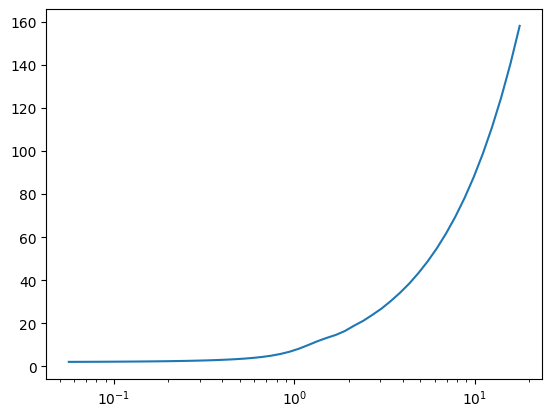

In [5]:
plot(sqrt(taus),1/rho)
xscale("log")

In [30]:
rho

array([0.47509437, 0.47199341, 0.46850746, 0.4645892 , 0.46018569,
       0.45523778, 0.44967955, 0.44343764, 0.43643077, 0.42856916,
       0.41975426, 0.40987867, 0.39882656, 0.38647477, 0.37269508,
       0.35735816, 0.34034013, 0.32153304, 0.30086104, 0.27830507,
       0.25393921, 0.22798284, 0.20087107, 0.17334046, 0.14650958,
       0.12189461, 0.10122886, 0.08588353, 0.07579954, 0.0685931 ,
       0.06093129, 0.05292369, 0.0472716 , 0.04177373, 0.03720843,
       0.03294525, 0.02925952, 0.0260129 , 0.02308582, 0.02051946,
       0.01824354, 0.01621273, 0.01441277, 0.01281377, 0.0113927 ,
       0.01012831, 0.00900527, 0.00800665, 0.00711869, 0.00632944])

Text(0.5, 0, ' $\\rho_n = \\rho (n-1)$')

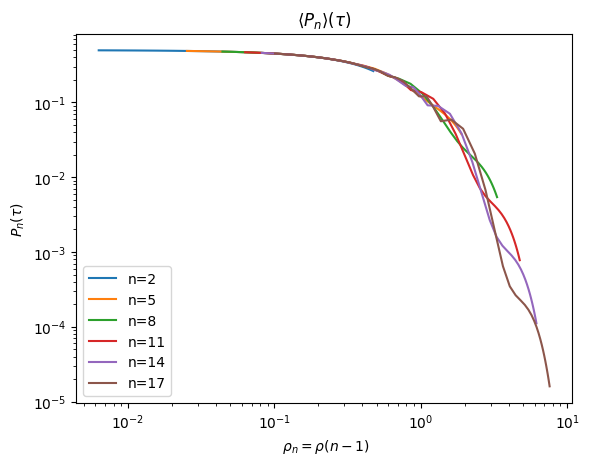

In [103]:
Delta_array=1/2-KZ_array.T

rho=2*(1/2-KZ_array[0])

for i in range(0,len(n_values),3):

    n = n_values[i]
    Pn = KZ_array[i]
    dPn = 1/2-Pn
    #Formula i derived
    #num = (1-n)**2
    #denom = (2*Pn-1)**2
    if i == 0:
        legendlabel = r"$\frac{n-1}{2l_q}$"
    else:
        legendlabel = ""

    lq= sqrt(taus*2)*2*pi
   # plot(lq,Delta_array[:,i],ls="--",color="black",label=legendlabel)
   # plot(taus,1/2*( (n-1)/lq-1/2*(n-1)*(n-2)/lq/lq),ls="--",color="black",label=legendlabel)
    #plot(taus,2.**(-n)*(1-2*(n-1)*rho),ls="--",color="black",label=legendlabel)
    #scatter((n-1)/lq,Pn,s=5)
    plot(rho*(n-1),Pn,label =f"n={n}")

#plot(rho,rho**(-2),"--k")

  #  plot(xi,xi*8,color="black",ls="--")
#xlim(0.1,8)
plt.title(r"$\langle P_n \rangle (\tau)$")
plt.ylabel(r"$P_{n}(\tau)$")
plt.legend()
plt.yscale("log")
#plt.ylim(0.1,1)
plt.xscale("log")
#plt.ylim(0,.75)
#plt.xlim(taus[0],taus[-1])
plt.xlabel(r" $\rho_n = \rho (n-1)$")
#plt.savefig("GroundStateDeviation_g1_approx.png")


Text(0.5, 0, '${l_q}$')

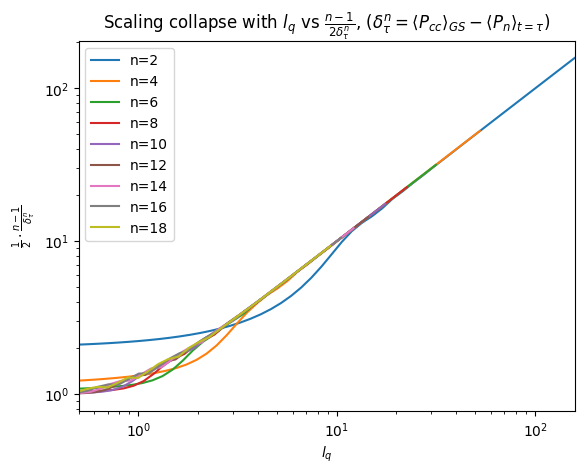

In [28]:
Delta_array=1/2-KZ_array.T
for i in range(0,len(n_values),2):
    n = n_values[i]
    Pn = KZ_array[i]
    dPn = 1/2-Pn
    #Formula i derived
    #num = (1-n)**2
    #denom = (2*Pn-1)**2
    if i == 0:
        legendlabel = r"$l_q$"
    else:
        legendlabel = ""
    #plot(taus,1/2*(n-1)/(2*dPn),ls="--",color="black",label=legendlabel)


    xi = 2*pi*sqrt(2*taus)
    plot(xi/(n-1),((1/(2*dPn))),label=f"n={n}")

    plt.hlines(0,xi[0],xi[-1],color="black",ls=":")

  #  plot(xi,xi*8,color="black",ls="--")
#xlim(sqrt(taus[0]),sqrt(taus[-1]))
plt.title(r"Scaling collapse with $l_q$ vs $\frac{n-1}{2 \delta^n_{\tau}}$, ($\delta^{n}_{\tau}=\langle P_{cc} \rangle_{GS}-\langle P_n \rangle_{t=\tau}$)")
plt.ylabel(r"$\frac{1}{2}\cdot \frac{n-1}{\delta^{n}_{\tau}}$")
plt.legend()
plt.yscale("log")
#plt.ylim(0,1)
plt.xscale("log")
#plt.ylim(1,100)
plt.xlim(xi[0],xi[-1])
plt.xlabel(r"${l_q}$")
#plt.savefig("GroundStateDeviation_g1_approx.png")

Text(0.5, 0, '$\\xi_n = \\frac{\\xi}{n-1}$')

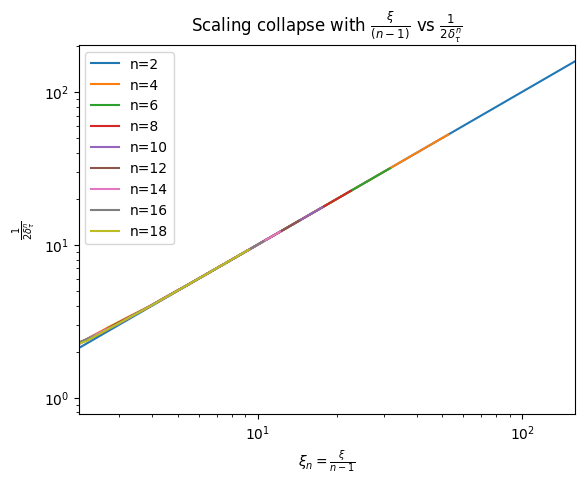

In [29]:
Delta_array=1/2-KZ_array.T
for i in range(0,len(n_values),2):
    n = n_values[i]
    Pn = KZ_array[i]
    dPn = 1/2-Pn
    #Formula i derived
    #num = (1-n)**2
    #denom = (2*Pn-1)**2
    if i == 0:
        legendlabel = r"$l_q$"
    else:
        legendlabel = ""
    #plot(taus,1/2*(n-1)/(2*dPn),ls="--",color="black",label=legendlabel)


    xi = 1/rho#2*pi*sqrt(2*taus)
   # plot(xi,xi,color="black",ls="--",label=legendlabel)
    #plot(xi,(((n-1)/(2*dPn))),label=f"n={n}")

    plot(xi/(n-1),((1/(2*dPn))),label=f"n={n}")
    plt.hlines(0,xi[0],xi[-1],color="black",ls=":")

#plot(xi,xi,color="black",ls="--",)
#xlim(sqrt(taus[0]),sqrt(taus[-1]))
plt.title(r"Scaling collapse with $\frac{\xi}{(n-1)}$ vs $\frac{1}{2 \delta^n_{\tau}}$")
plt.ylabel(r"$\frac{1}{2\delta^{n}_{\tau}}$")
plt.legend()
plt.yscale("log")
#plt.ylim(0,1)
plt.xscale("log")
#plt.ylim(1,100)
plt.xlim(xi[0],xi[-1])
plt.xlabel(r"$\xi_n = \frac{\xi}{n-1}$")
#plt.savefig("GroundStateDeviation_g1_approx.png")

(0.0, 1.0)

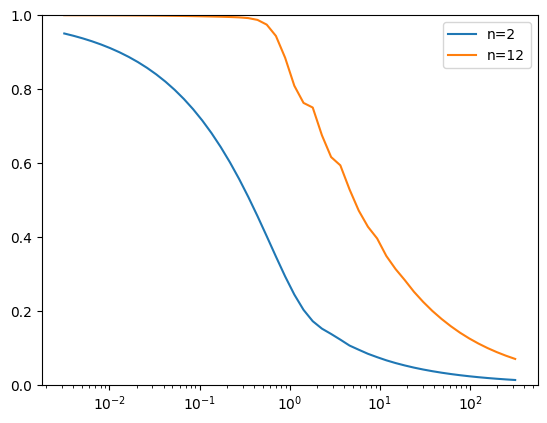

In [37]:
j = 10
n = n_values[j]

plot(taus,Delta_array[:,0]/(1/2-1/4.),label=f"n={n_values[0]}")
plot(taus,Delta_array[:,j]/(1/2-2.**(-n)),label=f"n={n_values[10]}")
#plt.loglog()
xscale("log")
plt.legend()
plt.ylim(0,1)


In [104]:
Xi = np.sqrt(taus)

print(Xi)

[ 0.05623413  0.06324416  0.07112804  0.0799947   0.08996667  0.10118172
  0.11379481  0.12798022  0.14393396  0.16187645  0.18205562  0.20475027
  0.230274    0.25897945  0.29126327  0.32757151  0.36840586  0.41433053
  0.46598007  0.52406814  0.58939733  0.66287032  0.74550229  0.83843498
  0.94295246  1.06049886  1.19269833  1.34137751  1.50859071  1.69664834
  1.90814883  2.14601451  2.413532    2.71439764  3.05276854  3.43332002
  3.86131021  4.34265274  4.88399837  5.49282697  6.17755082  6.94763085
  7.81370738  8.78774712  9.88320854 11.11522779 12.50082788 14.05915386
 15.81173736 17.7827941 ]


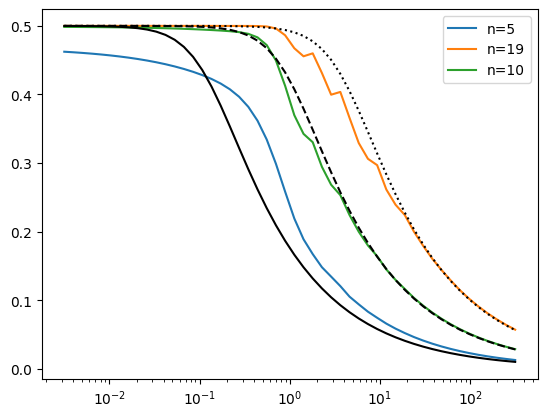

In [105]:
plot(taus,Delta_array[:,3],label=f"n={n_values[3]}")
plot(taus,Delta_array[:,-1],label=f"n={n_values[-1]}")
plot(taus,Delta_array[:,-10],label=f"n={n_values[-10]}")

def kz_crossover(tau, tau_star=1, rho0=0.5, alpha=2):
    return rho0 / (1 + (tau/tau_star)**alpha)**(0.5/alpha)  # 1D TFIM: ν=z=d=1

plot(taus,kz_crossover(taus,rho0=0.5,alpha=2,tau_star=1),color="black",ls="--")

plot(taus,kz_crossover(taus,rho0=0.5,alpha=2,tau_star=4),color="black",ls=":")
a= 2
b= 1/8
plot(taus,kz_crossover(taus,alpha=a,tau_star=b),color="black")

plt.xscale("log")
plt.legend()

In [106]:
ys =[]
xs= []
Scaling_Dim = 1/8
for i,ni in enumerate(n_values):
    delta_n = Delta_array[:,i]
    y_n = delta_n*ni**(0)
    x_n = ni/Xi
    ys.append(y_n)
    xs.append(x_n)


[]

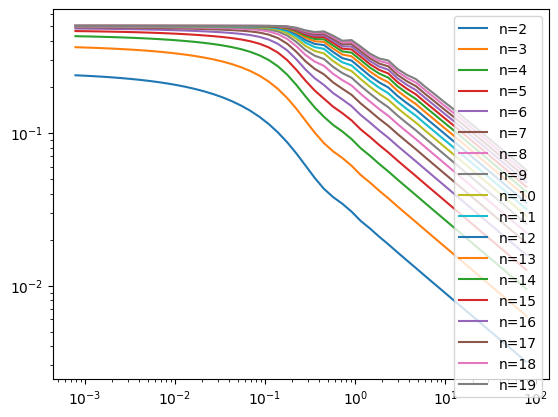

In [110]:
for i in range(len(ys)):
    plot(taus/sqrt(n-1),ys[i],label=f"n={n_values[i]}")

plt.legend()
plt.loglog()

100%|██████████| 25/25 [00:04<00:00,  5.22it/s]


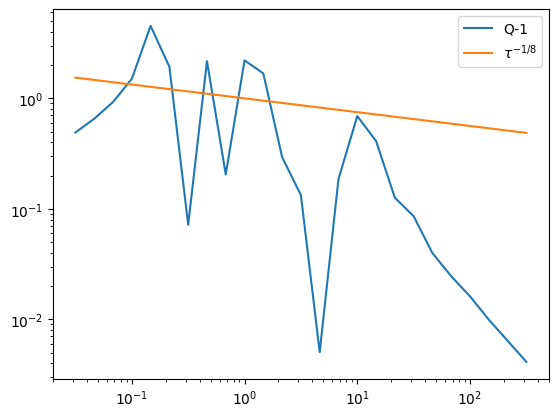

In [42]:
from tqdm import tqdm
taus_study = np.logspace(-1.5, 2.5, 25)
r = 20
C1, Cr, Cr1 = [], [], []

for tau in tqdm(taus_study):
    s = kz.state(256, tau, tau)
    C1.append(kz.sigma_general([0,1], s))
    Cr.append(kz.sigma_general([0,r], s))
    Cr1.append(kz.sigma_general([0,r+1], s))

C1  = np.array(C1)
Cr  = np.array(Cr)
Cr1 = np.array(Cr1)

Q = (Cr1/Cr) / C1
y = np.abs(Q - 1)              # isolates non-Poisson piece

plot(taus_study, y, label='Q-1')
plot(taus_study, taus_study**(-1/8), label=r'$\tau^{-1/8}$')
xscale("log"); plt.yscale("log"); legend()


In [43]:
from tqdm import tqdm
taus_study = np.logspace(-1.5,2.5,100)
r= 20
p_tau=[]
dat= []
for tau in tqdm(taus_study):
    L = np.arange(1,25)
    s = kz.state(256,tau,tau)
    p = 1/2*(1-kz.sigma_general([0,1],s))
    p_tau.append(p)
    dat.append(np.array(kz.sigma_general([0,r],s)))

p_tau=np.array(p_tau)
dat= np.array(dat)



 29%|██▉       | 29/100 [00:04<00:10,  6.59it/s]


KeyboardInterrupt: 

ValueError: x and y must have same first dimension, but have shapes (100,) and (29,)

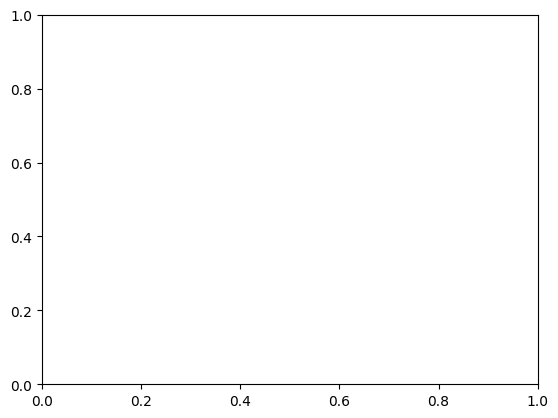

In [44]:
plot(taus_study,dat)
plot(taus/n_values[10],Delta_array[:,10]/(1/2-2.**-n_values[10]))

plot(taus/n_values[-1],Delta_array[:,-1]*2)
xscale("log")

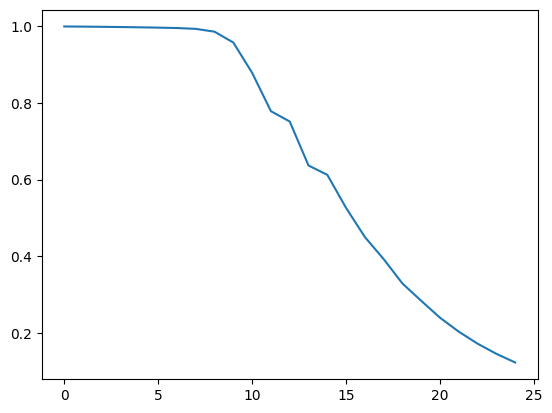

In [ ]:
plot(dat12)

In [45]:
import kblock_ising_model as kb

k = kb.k_vals(1024)
k = k[np.abs(k)>=2]
U = kb.U(k,0)
kb.P_n(4,U,k)

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/KZ_mech_and_Scaling_dim/../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)


np.float64(0.35390768030260883)

In [46]:
epsilon = kb.k_vals(1024)
epsilon= epsilon[epsilon>=0]
dat1=[]
dat2=[]
dat3=[]
for e in tqdm(epsilon):
    k = kb.k_vals(1024)
    k = k[np.abs(k)>=e]
    U = kb.U(k,0)
    dat1.append(kb.P_n(2,U,k))
    dat2.append(kb.P_n(6,U,k))
    dat3.append(kb.P_n(12,U,k))


  1%|          | 5/512 [00:12<21:22,  2.53s/it]


KeyboardInterrupt: 

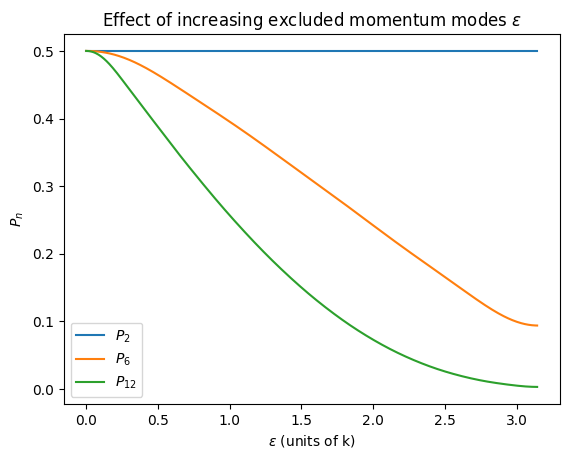

In [173]:
plot(epsilon,dat1,label=r"$P_2$")
plot(epsilon,dat2,label=r"$P_6$")
plot(epsilon,dat3,label=r"$P_{12}$")
plt.title(r"Effect of increasing excluded momentum modes $\epsilon$")
plt.xlabel(r"$\epsilon$ (units of k)")
plt.ylabel(r"$P_n$")

plt.legend()
plt.savefig("epislon_increase.pdf")

In [47]:
def Gnn(n,r,t,tau):
    s = kz.state(512,tau,t)
    PnPn = kz.P_n_correlations(n,r,s)
    Pn = kz.P_n(n,s)
    return PnPn-Pn**2

In [111]:
def scaling_collapse(ts,ns,u=1,v=1):
    #Set L = 512 which works fine
    L = 512
    #Empty Array
    data= np.empty([len(ns),len(ts)])
    #Loop over taus
    for tau_i in tqdm(range(len(ts))):
        #Define Variables
        tau = ts[tau_i]
        t = sqrt(tau)*v
        l = int(sqrt(tau))*u 
        #Define state
        s = kz.state(L,tau,t)
        for n_i in range(len(ns)):
            n = ns[n_i]
            P = kz.P_n(n,s)
            PP = kz.P_n_correlations(n,l,s)
            #Append Correlation
            data[n_i,tau_i]= PP-P*P
    return data

In [112]:
ns = np.array([1,2,3,4,5])
ts= np.logspace(0,3,25)

data = scaling_collapse(ts,ns)

  0%|          | 0/25 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/KZ_mech_and_Scaling_dim/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
 92%|█████████▏| 23/25 [00:19<00:03,  1.96s/it]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
 96%|█████████▌| 24/25 [00:23<00:02,  2.72s/it]/Users/kristianmunnikhuis/Desktop/subsyst

In [ ]:
rho = array([1/2-kz.sigma_general([0,1],s) for s in state])

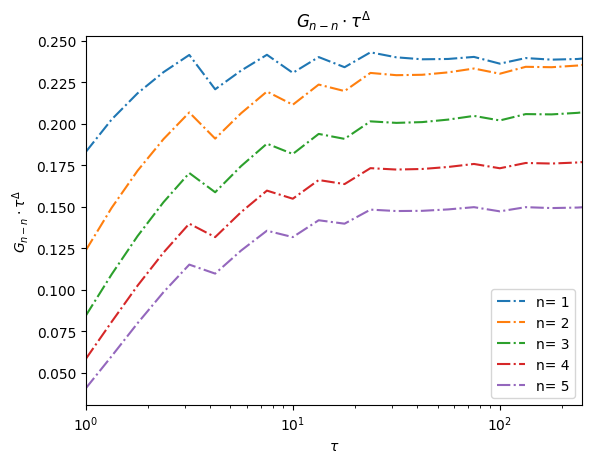

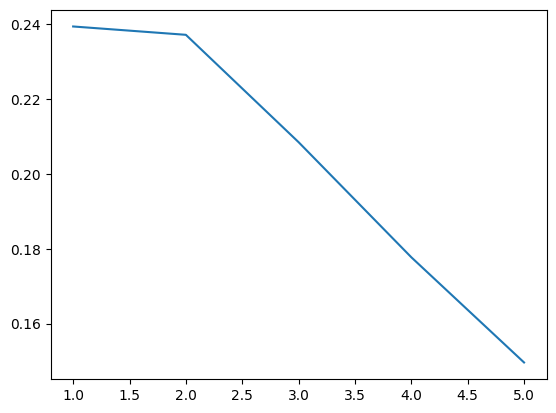

In [59]:
# plot(ns,data[:,::5])
# plt.xlabel(r"$n$")
# plt.ylabel(r"$G_{n-n}$")

# plt.show()
dd = []
for i, d in enumerate(data):
    x = [ts[i]**(1/8)*d[i] for i in range(len(d))]
    plot(ts,x,label=f"n= {ns[i]}",ls="dashdot")
    dd.append(x[-2])
#plot(ts,data[0])
plt.title(r"$G_{n-n} \cdot \tau^{\Delta}$")
xlim(taus[0],taus[-2])
xscale("log")
#yscale("log")
xlabel(r"$\tau$")
ylabel(r"$G_{n-n} \cdot \tau^{\Delta}$")
legend()
plt.show()
plt.plot(ns,dd)
#plt.savefig("Gnn_tau_flatline.pdf")

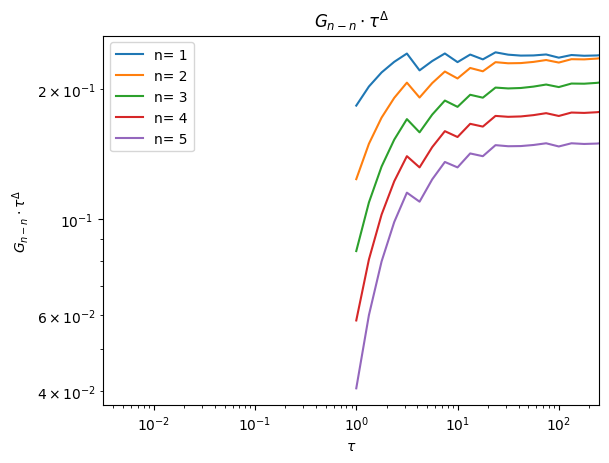

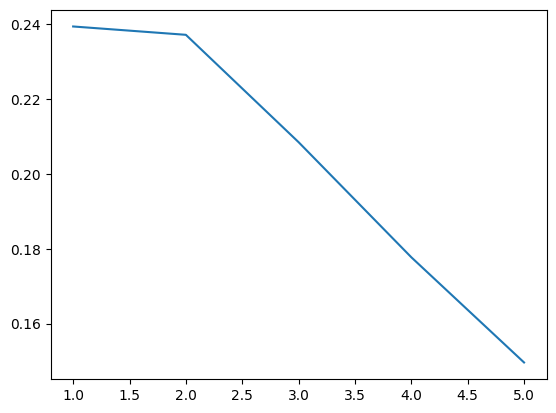

In [51]:
# plot(ns,data[:,::5])
# plt.xlabel(r"$n$")
# plt.ylabel(r"$G_{n-n}$")

# plt.show()
dd = []
for i, d in enumerate(data):
    x = [ts[i]**(1/8)*d[i] for i in range(len(d))]
    plot(ts,x,label=f"n= {ns[i]}")
    dd.append(x[-2])
#plot(ts,data[0])
plt.title(r"$G_{n-n} \cdot \tau^{\Delta}$")
xlim(taus[0],taus[-2])
xscale("log")
yscale("log")
xlabel(r"$\tau$")
ylabel(r"$G_{n-n} \cdot \tau^{\Delta}$")
legend()
plt.show()
plt.plot(ns,dd)
#plt.savefig("Gnn_tau_flatline.pdf")

In [596]:
dd/dd[0]

array([1.        , 0.99069778, 0.87086104, 0.74242444, 0.62500998,
       0.52277655, 0.43562004, 0.36212587])

(1.0, 8.0)

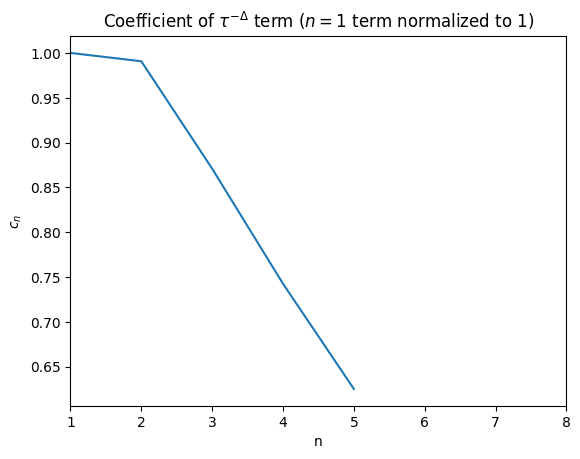

In [52]:
final_values = np.array(dd)

plt.plot(ns,final_values/final_values[0])

plt.title(r"Coefficient of $\tau^{-\Delta}$ term ($n=1$ term normalized to 1)")
plt.xlabel("n")
plt.ylabel("$c_n$")
plt.xlim(1,8)

In [53]:
scatter(ts,dat1/1.35,label=r"$G_{1- 1}(r_q,t_q)$")
scatter(ts,dat2*1,label=r"$G_{4- 4}(r_q,t_q)$")

plot(ts,(ts)**(-1/8)/4.5,label=r"$l_q^{-2\Delta_\sigma}=\tau^{-\Delta}$")
plt.xscale("log")

yscale("log")
xlabel(r"Quench Time $\tau$")
ylabel(r"$G_{1 - 1} ( r_q, t_q)$")
plt.title(r"Scale invariant function with $r_q=t_q=\sqrt{\tau}$")
plt.legend()
#plt.savefig("KZCOllapse_P2P2.pdf")

TypeError: unsupported operand type(s) for /: 'list' and 'float'

100%|██████████| 25/25 [00:09<00:00,  2.64it/s]


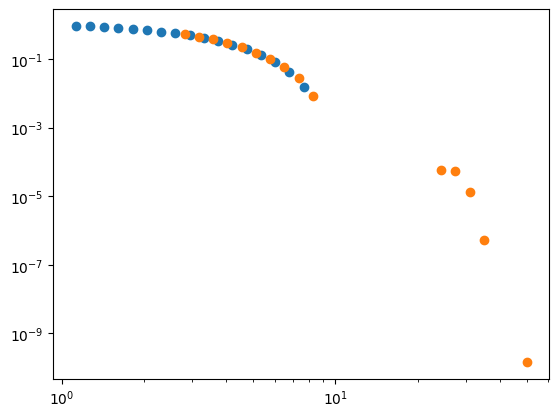

In [54]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

for r in [20,50]:
    taus = np.logspace(0, 2.5, 25)
    Delta = 1/8

    X, Y = [], []

    for tau in tqdm(taus):
        tQ = np.sqrt(tau)
        lQ = tQ
        u = 1.0
        t = u * tQ
        s = kz.state(512, tau, t)
        G = kz.sigma_general([0, r], s)   # no rescaling here
        X.append(r / lQ)
        Y.append((lQ**(2*Delta)) * G)

    plt.loglog(X, Y, 'o')
plt.show()